# Dust Percentage Analysis by Month

This notebook analyzes the `DustSCAN_2022.nc` dataset to identify the months where the dust percentage is the highest.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Path to the dataset
file_path = os.path.expanduser('~/Downloads/DustSCAN_2022.nc')

# Load the dataset
try:
    ds = xr.open_dataset(file_path, engine='netcdf4')
    print("Dataset loaded successfully.")
    print(ds)
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully.
<xarray.Dataset>
Dimensions:     (time: 8718, lat: 148, lon: 357, band: 3)
Coordinates:
  * time        (time) datetime64[ns] 2021-12-01 ... 2022-11-30T23:00:00
    latitude    (lat, lon) float64 ...
    longitude   (lat, lon) float64 ...
Dimensions without coordinates: lat, lon, band
Data variables:
    dust_rgb    (time, lat, lon, band) float32 ...
    plume_id    (time, lat, lon) int32 ...
    sun_zenith  (time, lat, lon) float64 ...
    cloud_mask  (time, lat, lon) int32 ...
    pdi         (time, lat, lon) float64 ...
Attributes:
    Conventions:  CF-1.10
    title:        DustSCAN 2022
    description:  SEVIRI derived dust plumes dataset from 2021-12-01 00:00 to...
    source:       DustSCAN: A Five Year (2018-2022) Hourly Dataset of Dust Pl...
    version:      1.0
    reference:    doi: x
    Authors:      Faisal AlNasser and Dara Entekahbi
    history:      2023-12-02 19:46:51.150913 Python


In [3]:
# Group by month and calculate the percentage of dust pixels
# Dust is present where plume_id > 0

# Create a boolean mask for dust presence
is_dust = ds['plume_id'] > 0

# Group by month ('time.month') and calculate the mean
# The mean of a boolean array gives the percentage of True values
monthly_dust_fraction = is_dust.groupby('time.month').mean(dim=['time', 'lat', 'lon'])

# Convert fraction to percentage
monthly_dust_percentage = monthly_dust_fraction * 100

print("Monthly Dust Percentage:")
print(monthly_dust_percentage.values)

Monthly Dust Percentage:
[0.53181392 0.86827672 1.50588117 1.01641575 1.55831658 2.30147978
 1.60515251 1.46465301 0.63836233 0.63085327 0.10442829 0.23878054]


In [ ]:
# Convert the result to a pandas DataFrame for easier plotting and tabular view
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
available_months = [months[i-1] for i in monthly_dust_percentage.month.values]

df_dust = pd.DataFrame({
    'Month': available_months,
    'Dust Percentage (%)': monthly_dust_percentage.values
})

# Sort by dust percentage descending to see the highest months first
df_sorted = df_dust.sort_values(by='Dust Percentage (%)', ascending=False).reset_index(drop=True)
df_sorted

,Month,Dust Percentage (%)
0,Jun,2.301480
1,Jul,1.605153
2,May,1.558317
3,Mar,1.505881
4,Aug,1.464653
5,Apr,1.016416
6,Feb,0.868277
7,Sep,0.638362
8,Oct,0.630853
9,Jan,0.531814


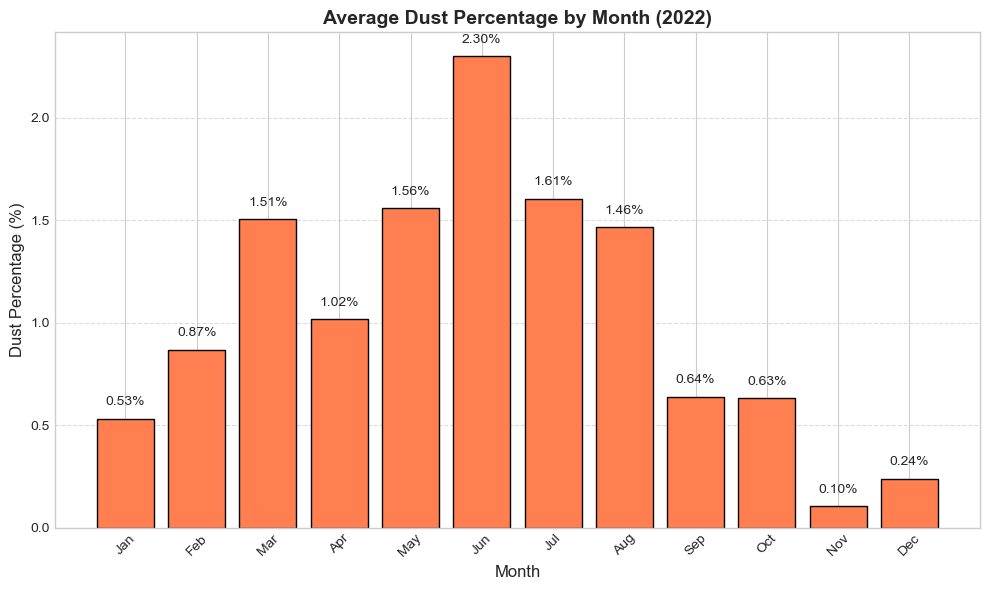

In [5]:
# Plotting the results
plt.figure(figsize=(10, 6))
plt.bar(df_dust['Month'], df_dust['Dust Percentage (%)'], color='coral', edgecolor='black')
plt.title('Average Dust Percentage by Month (2022)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Dust Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(df_dust['Dust Percentage (%)']):
    plt.text(i, val + 0.05, f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()